# Analysing Resource Estimation Results

This notebook demonstrates how to inspect and analyse the output of the quantum resource estimator. We will:

1. Define a Q# program and run a resource estimation that produces multiple Pareto-optimal results
2. Understand the estimation statistics
3. Access individual result entries and their properties
4. Inspect the ISA used in each result
5. Inspect the magic-state factories
6. Add custom columns and plot the Pareto frontier

In [1]:
import pandas as pd

from qdk.qre import estimate, property_name, instruction_name, PSSPC, LatticeSurgery
from qdk.qre.models import GateBased, SurfaceCode, RoundBasedFactory
from qdk.qre.application import QSharpApplication
from qdk.qre.instruction_ids import T, LATTICE_SURGERY
from qdk.qre.property_keys import (
    PHYSICAL_COMPUTE_QUBITS,
    PHYSICAL_FACTORY_QUBITS,
    PHYSICAL_MEMORY_QUBITS,
    LOGICAL_COMPUTE_QUBITS,
    ALGORITHM_COMPUTE_QUBITS,
    NUM_TS_PER_ROTATION,
)

## 1. Define a Q# program and run estimation

We define a Q# program that performs eight parallel 8-bit ripple-carry additions, each preceded by single-qubit rotations. The rotations are important because they introduce T-gate decomposition, which makes the PSSPC trace transform explore multiple configurations (one for each `num_ts_per_rotation` value).

In [2]:
%%qsharp

import Std.Arithmetic.*;
import Std.Math.*;
import Std.Convert.*;

operation EstimateAdder() : Unit {
    for _ in 1..8 {
        use a = Qubit[8];
        use b = Qubit[8];
        for i in 0..7 {
            Ry(PI() / IntAsDouble(i + 2), a[i]);
        }
        RippleCarryCGIncByLE(a, b);
    }
}

To further increase the variety of Pareto-optimal points, we vary the `slow_down_factor` in the `LatticeSurgery` trace transform. This factor multiplies the trace depth for space/time trade-offs.

In [3]:
from qdk.code import EstimateAdder

app = QSharpApplication(EstimateAdder)
arch = GateBased(error_rate=1e-4, gate_time=100, measurement_time=500)

results = estimate(
    app,
    arch,
    isa_query=SurfaceCode.q() * RoundBasedFactory.q(),
    trace_query=PSSPC.q() * LatticeSurgery.q(slow_down_factor=[1.0, 1.5, 2.0, 3.0, 4.0]),
    max_error=0.01,
)

print(f"Number of Pareto-optimal results: {len(results)}")
results.as_frame()

Number of Pareto-optimal results: 6


,qubits,runtime,error
0,8967,0 days 00:00:00.009200,0.007875
1,10927,0 days 00:00:00.006900,0.007006
2,14847,0 days 00:00:00.004600,0.006136
3,18767,0 days 00:00:00.003450,0.005702
4,22771,0 days 00:00:00.003220,0.004406
5,26607,0 days 00:00:00.002300,0.005267


Each row in the table is a Pareto-optimal configuration: no other result achieves both fewer qubits *and* a shorter runtime while staying within the error budget. The trade-off is visible: results with fewer qubits tend to have longer runtimes, and vice versa.

## 2. Estimation statistics

The estimator explores a large combinatorial design space. It generates multiple *traces* from the application (one for each combination of trace-transform parameters), and multiple *ISAs* from the architecture (one for each combination of QEC code distance and factory protocol). Every (trace, ISA) pair is an estimation job.

The `stats` attribute summarises this exploration.

In [4]:
stats = results.stats
print(f"Traces explored:        {stats.num_traces}")
print(f"ISAs explored:          {stats.num_isas}")
print(f"Total estimation jobs:  {stats.total_jobs}")
print(f"Successful estimates:   {stats.successful_estimates}")
print(f"Pareto-optimal results: {stats.pareto_results}")

Traces explored:        160
ISAs explored:          1248
Total estimation jobs:  49005
Successful estimates:   990
Pareto-optimal results: 6


Here is what each statistic means:

- **Traces explored:** The number of distinct traces generated from the application. Each combination of trace-transform parameters produces a separate trace. In our case, the PSSPC transform enumerates 16 values for `num_ts_per_rotation` (5 through 20) and we specified 5 values for `slow_down_factor`, giving 16 × 5 × 2 = 160 traces (the × 2 comes from the PSSPC `ccx_magic_states` boolean, which defaults to `[True, False]`).

- **ISAs explored:** The number of distinct instruction sets generated from the architecture. Each combination of surface code distance and factory distillation protocol produces one ISA. The estimator systematically enumerates code distances and factory configurations, producing a large set of candidate ISAs.

- **Total estimation jobs:** The total number of (trace, ISA) pairs evaluated. In principle this would be `num_traces × num_isas`, but the estimator uses pruning strategies (based on a provenance graph) to skip ISAs that are dominated on per-instruction metrics, so the actual number is typically much smaller.

- **Successful estimates:** The number of jobs that produced a valid result, i.e., the total error stayed within the `max_error` budget. Jobs where the error budget is exceeded are discarded.

- **Pareto-optimal results:** The number of results retained after Pareto filtering. A result is Pareto-optimal if no other result is simultaneously better in both physical qubits and runtime. This is the final set returned in the `EstimationTable`.

## 3. Accessing individual results

Results are stored in an `EstimationTable`, which behaves like a list of `EstimationTableEntry` objects. Each entry exposes:

- **`qubits`**, **`runtime`**, **`error`:** the headline metrics
- **`properties`:** a dictionary of additional metrics (qubit partition, algorithm parameters, etc.)
- **`source`:** an instruction source graph showing how logical instructions are implemented
- **`factories`:** a dictionary mapping instruction IDs to factory results

Note that the input *trace* itself is not part of the result (traces can be very large), but key properties derived from it, such as algorithmic qubit counts and decomposition parameters, are stored in the `properties` dictionary.

In [5]:
entry = results[0]

print(f"Total physical qubits: {entry.qubits}")
print(f"Runtime:               {pd.Timedelta(entry.runtime, unit='ns')}")
print(f"Error:                 {entry.error:.6f}")

Total physical qubits: 8967
Runtime:               0 days 00:00:00.009200
Error:                 0.007875


### Result properties

The `properties` dictionary carries additional metrics attached during estimation. The keys are integer identifiers; use `property_name()` to get human-readable names.

These properties include information derived from the trace (such as algorithmic qubit counts and the number of T states per rotation used in the PSSPC decomposition) as well as information from the estimation itself (such as the physical qubit partition and evaluation time).

In [6]:
props = {property_name(k): v for k, v in entry.properties.items()}
for name, value in props.items():
    print(f"  {name}: {value}")

  LOGICAL_MEMORY_QUBITS: 0
  EVALUATION_TIME: 7728507
  NUM_TS_PER_ROTATION: 12
  ALGORITHM_COMPUTE_QUBITS: 24
  PHYSICAL_COMPUTE_QUBITS: 3087
  ALGORITHM_MEMORY_QUBITS: 0
  LOGICAL_COMPUTE_QUBITS: 63
  PHYSICAL_FACTORY_QUBITS: 5880


Properties can also be accessed by key directly using the constants from `property_keys`:

In [ ]:
print(f"Num Ts per rotation:      {entry.properties.get(NUM_TS_PER_ROTATION, 'N/A')}")
print(f"Algorithm compute qubits: {entry.properties.get(ALGORITHM_COMPUTE_QUBITS, 'N/A')}")
print(f"Logical compute qubits:   {entry.properties.get(LOGICAL_COMPUTE_QUBITS, 'N/A')}")
print(f"Physical compute qubits:  {entry.properties.get(PHYSICAL_COMPUTE_QUBITS, 0)}")
print(f"Physical factory qubits:  {entry.properties.get(PHYSICAL_FACTORY_QUBITS, 0)}")
print(f"Physical memory qubits:   {entry.properties.get(PHYSICAL_MEMORY_QUBITS, 0)}")

Num Ts per rotation:     12
Algorithm compute qubits: 24
Logical compute qubits:  63
Physical compute qubits: 3087
Physical factory qubits: 5880
Physical memory qubits:  0


### Pre-configured columns for qubit partition and factories

The `EstimationTable` provides convenience methods to add commonly used columns. `add_qubit_partition_column()` breaks the total physical qubit count into compute, factory, and memory qubits. `add_factory_summary_column()` adds a human-readable summary of the factories used (e.g., `20×T` meaning 20 copies of a T-state factory).

In [8]:
results.add_qubit_partition_column()
results.add_factory_summary_column()

results.as_frame()

,qubits,runtime,error,physical_compute_qubits,physical_factory_qubits,physical_memory_qubits,factories
0,8967,0 days 00:00:00.009200,0.007875,3087,5880,0,6×T
1,10927,0 days 00:00:00.006900,0.007006,3087,7840,0,8×T
2,14847,0 days 00:00:00.004600,0.006136,3087,11760,0,12×T
3,18767,0 days 00:00:00.003450,0.005702,3087,15680,0,16×T
4,22771,0 days 00:00:00.003220,0.004406,6111,16660,0,17×T
5,26607,0 days 00:00:00.002300,0.005267,3087,23520,0,24×T


## 4. Inspecting the ISA of an estimation result

Each estimation result carries an *instruction source graph* that describes how logical instructions are implemented in terms of lower-level operations. The `source` attribute of each result entry provides this graph.

Each root node in the graph is a logical instruction (e.g., `T`, `LATTICE_SURGERY`). Nodes also reference the *transform* that produced them (e.g., the surface code QEC scheme or the architecture itself), and may have child nodes representing the physical instructions they are built from.

In [9]:
print("Instruction source graph for the first result:")
print(entry.source)

Instruction source graph for the first result:
LATTICE_SURGERY @ SurfaceCode(crossing_prefactor=0.03, error_correction_threshold=0.01, one_qubit_gate_depth=1, two_qubit_gate_depth=4, distance=5)
  CNOT @ GateBased(error_rate=0.0001, gate_time=100, measurement_time=500, two_qubit_gate_time=100)
  H @ GateBased(error_rate=0.0001, gate_time=100, measurement_time=500, two_qubit_gate_time=100)
  MEAS_Z @ GateBased(error_rate=0.0001, gate_time=100, measurement_time=500, two_qubit_gate_time=100)
T @ RoundBasedFactory(code_query=_ComponentQuery(component=<class 'qsharp.qre.models.qec._surface_code.SurfaceCode'>, source=RootNode(), kwargs={}), physical_qubit_calculation=<built-in function sum>)
  T @ GateBased(error_rate=0.0001, gate_time=100, measurement_time=500, two_qubit_gate_time=100)


### Accessing individual instructions

The instruction source graph can be navigated like a dictionary using instruction IDs. For each node, you can inspect the instruction's properties (space, time, error rate) and the transform that produced it.

In [10]:
if T in entry.source:
    t_node = entry.source[T]
    t_inst = t_node.instruction
    print("T instruction:")
    print(f"  ID:         {instruction_name(t_inst.id)}")
    print(f"  Encoding:   {'LOGICAL' if t_inst.encoding == 1 else 'PHYSICAL'}")
    print(f"  Arity:      {t_inst.arity}")
    print(f"  Space:      {t_inst.space()} physical qubits")
    print(f"  Time:       {t_inst.time()} ns")
    print(f"  Error rate: {t_inst.error_rate():.2e}")
    if t_node.transform is not None:
        print(f"  Transform:  {t_node.transform}")

T instruction:
  ID:         T
  Encoding:   LOGICAL
  Arity:      1
  Space:      980 physical qubits
  Time:       65000 ns
  Error rate: 2.13e-07
  Transform:  RoundBasedFactory(code_query=_ComponentQuery(component=<class 'qsharp.qre.models.qec._surface_code.SurfaceCode'>, source=RootNode(), kwargs={}), physical_qubit_calculation=<built-in function sum>)


In [ ]:
if LATTICE_SURGERY in entry.source:
    ls_node = entry.source[LATTICE_SURGERY]
    ls_inst = ls_node.instruction
    print("LATTICE_SURGERY instruction:")
    print(f"  ID:                   {instruction_name(ls_inst.id)}")
    print(f"  Encoding:             {'LOGICAL' if ls_inst.encoding == 1 else 'PHYSICAL'}")
    # Arity is None for variable-arity instructions
    print(f"  Arity:                {ls_inst.arity}")
    # For variable-arity instructions, query specific arities
    print(f"  Error rate (arity=1): {ls_inst.error_rate(1):.2e}")
    if ls_node.transform is not None:
        print(f"  Transform:            {ls_node.transform}")

LATTICE_SURGERY instruction:
  ID:         LATTICE_SURGERY
  Encoding:   LOGICAL
  Arity:      None
  Error rate (arity=1): 3.00e-08
  Transform:  SurfaceCode(crossing_prefactor=0.03, error_correction_threshold=0.01, one_qubit_gate_depth=1, two_qubit_gate_depth=4, distance=5)


## 5. Inspecting factories

Magic-state factories distill high-fidelity resource states (e.g., T states) from noisy physical operations. The `factories` dictionary on each result entry maps instruction IDs to `FactoryResult` objects with four properties:

- **`copies`:** the number of factory instances running in parallel
- **`runs`:** the number of distillation rounds each factory performs
- **`states`:** the total number of resource states produced
- **`error_rate`:** the output error rate per produced state

In [12]:
print("Factories in the first result:")
for inst_id, factory in entry.factories.items():
    print(f"\n  {instruction_name(inst_id)} factory:")
    print(f"    Copies:     {factory.copies}")
    print(f"    Runs:       {factory.runs}")
    print(f"    States:     {factory.states}")
    print(f"    Error rate: {factory.error_rate:.2e}")

Factories in the first result:

  T factory:
    Copies:     6
    Runs:       141
    States:     808
    Error rate: 2.13e-07


### Comparing factories across Pareto-optimal results

Different points on the Pareto frontier use different factory configurations. Results that favour fewer qubits typically use fewer factory copies (at the cost of longer runtime), while faster results need more factory copies running in parallel.

In [13]:
factory_data = []
for i, e in enumerate(results):
    for inst_id, factory in e.factories.items():
        factory_data.append({
            "result": i,
            "instruction": instruction_name(inst_id),
            "copies": factory.copies,
            "runs": factory.runs,
            "states": factory.states,
            "factory_error_rate": factory.error_rate,
            "total_qubits": e.qubits,
            "runtime_ns": e.runtime,
        })

pd.DataFrame(factory_data)

,result,instruction,copies,runs,states,factory_error_rate,total_qubits,runtime_ns
0,0,T,6,141,808,2.130350e-07,8967,9200000
1,1,T,8,106,808,2.130350e-07,10927,6900000
2,2,T,12,70,808,2.130350e-07,14847,4600000
3,3,T,16,53,808,2.130350e-07,18767,3450000
4,4,T,17,49,808,2.130350e-07,22771,3220000
5,5,T,24,35,808,2.130350e-07,26607,2300000


## 6. Adding custom columns and plotting

The `EstimationTable` supports adding custom columns with `add_column(name, function)` and `add_property_column(key)`. With `add_column`, the function receives an `EstimationTableEntry` and returns the value for that column. With `add_property_column`, the column is automatically populated from the entry's `properties` dictionary using the given key. These methods are useful for surfacing specific metrics, such as per-instruction error rates, factory state counts, or decomposition parameters, directly in the results table.

In [14]:
results.add_column(
    "t_error_rate",
    lambda r: r.source[T].instruction.error_rate() if T in r.source else None,
)
results.add_column(
    "logical_error_rate",
    lambda r: r.source[LATTICE_SURGERY].instruction.error_rate(1) if LATTICE_SURGERY in r.source else None,
)
results.add_column(
    "t_states",
    lambda r: r.factories[T].states if T in r.factories else 0,
)
results.add_property_column(NUM_TS_PER_ROTATION)

results.as_frame()

,qubits,runtime,error,physical_compute_qubits,physical_factory_qubits,physical_memory_qubits,factories,t_error_rate,logical_error_rate,t_states,num_ts_per_rotation
0,8967,0 days 00:00:00.009200,0.007875,3087,5880,0,6×T,2.130350e-07,3.000000e-08,808,12
1,10927,0 days 00:00:00.006900,0.007006,3087,7840,0,8×T,2.130350e-07,3.000000e-08,808,12
2,14847,0 days 00:00:00.004600,0.006136,3087,11760,0,12×T,2.130350e-07,3.000000e-08,808,12
3,18767,0 days 00:00:00.003450,0.005702,3087,15680,0,16×T,2.130350e-07,3.000000e-08,808,12
4,22771,0 days 00:00:00.003220,0.004406,6111,16660,0,17×T,2.130350e-07,3.000000e-10,808,12
5,26607,0 days 00:00:00.002300,0.005267,3087,23520,0,24×T,2.130350e-07,3.000000e-08,808,12


### Plotting the Pareto frontier

The `plot` method (or the standalone `plot_estimates` function) creates a log-log scatter plot of the Pareto frontier, with runtime on the x-axis and physical qubits on the y-axis. Each point represents a configuration that is optimal in the sense that no other result achieves both fewer qubits *and* a shorter runtime.

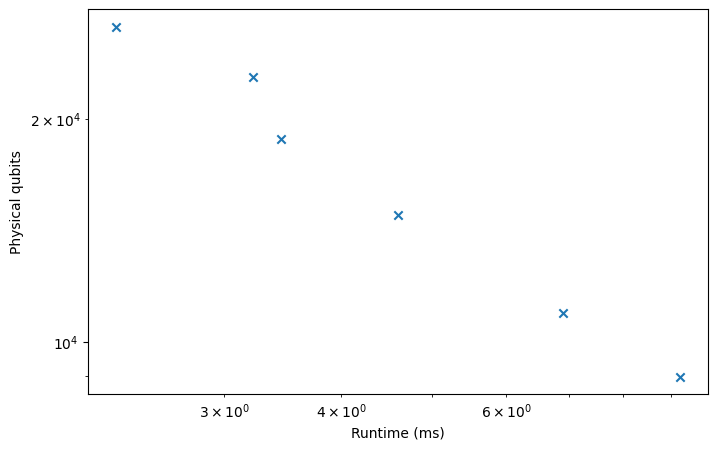

In [15]:
results.plot(figsize=(8, 5), runtime_unit="ms")

## Summary

| What to inspect | How to access it |
|---|---|
| Top-level metrics | `entry.qubits`, `entry.runtime`, `entry.error` |
| Estimation statistics | `results.stats` → `.num_traces`, `.num_isas`, `.total_jobs`, `.successful_estimates`, `.pareto_results` |
| Result properties | `entry.properties[KEY]` with keys from `property_keys`; use `property_name(k)` for names |
| Instruction source graph | `entry.source[INSTRUCTION_ID]` → `.instruction`, `.transform` |
| Instruction details | `instruction.space()`, `.time()`, `.error_rate()` |
| Magic-state factories | `entry.factories[INSTRUCTION_ID]` → `.copies`, `.runs`, `.states`, `.error_rate` |
| Qubit partition | `results.add_qubit_partition_column()` or via property keys |
| Custom table columns | `results.add_column(name, function)` or `results.add_property_column(key)` |
| Plotting | `results.plot()` or `plot_estimates(results)` |

Note that the input *trace* is not included in the results (traces can be very large), but key properties derived from it, such as algorithmic qubit counts and decomposition parameters, are available through the `properties` dictionary.